In [1]:
# =========================================================
# CELL 1 — Imports & plotting style
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Publication font settings
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica"]
plt.rcParams["font.size"] = 12

plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
# =========================================================
# CELL 2 — Read Excel file
# =========================================================
file_name = "Haga_original cordinates.xlsx"
df = pd.read_excel(file_name)

df.columns = [c.strip() for c in df.columns]

required_cols = ["Hole", "X_start", "Y_start", "Z_start", "X_end", "Y_end", "Z_end"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Convert comma decimals to float
num_cols = ["X_start", "Y_start", "Z_start", "X_end", "Y_end", "Z_end"]
for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
        .astype(float)
    )

if "Length" in df.columns:
    df["Length"] = (
        df["Length"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
        .astype(float)
    )

df["Hole"] = pd.to_numeric(df["Hole"], errors="coerce")
df = df.sort_values("Hole").reset_index(drop=True)



In [2]:
# =========================================================
# CELL 3 — Model parameters
# =========================================================
At_deg = 340.0
Pt_deg = 0.0
theta_deg = 165.0
delta_deg = 45.0
beta_deg = 14.0

At = math.radians(At_deg)
Pt = math.radians(Pt_deg)
theta = math.radians(theta_deg)
delta = math.radians(delta_deg)
beta = math.radians(beta_deg)

center = np.array([1.47755153e+05, 6.39762933e+06, -1.80261765e+01])

print("Center:", center)

Center: [ 1.47755153e+05  6.39762933e+06 -1.80261765e+01]


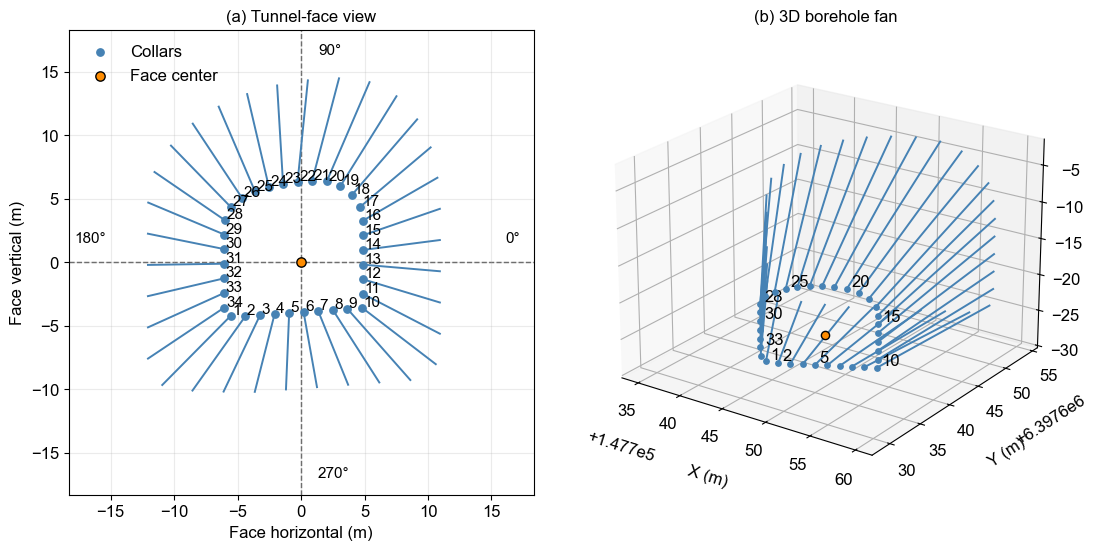

Saved to: C:\Users\abisheks\OneDrive - NTNU\Hit rate\Python\Hit_rate_Final_code\hit_rate_outputs


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 1. Plot settings
# =========================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

out_dir = Path("hit_rate_outputs")
out_dir.mkdir(exist_ok=True)

# =========================================================
# 2. Read Excel file
# =========================================================

file_name = "Haga_original cordinates.xlsx"

df = pd.read_excel(file_name)
df.columns = [c.strip() for c in df.columns]

required_cols = ["Hole", "X_start", "Y_start", "Z_start", "X_end", "Y_end", "Z_end"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns in Excel file: {missing}")

num_cols = ["X_start", "Y_start", "Z_start", "X_end", "Y_end", "Z_end"]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
        .astype(float)
    )

df["Hole"] = pd.to_numeric(df["Hole"], errors="coerce")
df = df.sort_values("Hole").reset_index(drop=True)

# =========================================================
# 3. Tunnel-face center
# =========================================================

center = np.array([1.47755153e+05, 6.39762933e+06, -1.80261765e+01])

# =========================================================
# 4. Geometry preparation
# =========================================================

S = df[["X_start", "Y_start", "Z_start"]].to_numpy(dtype=float)
E = df[["X_end", "Y_end", "Z_end"]].to_numpy(dtype=float)
V = E - S
C = center.copy()

# =========================================================
# 5. Tunnel-face projection
# =========================================================

Xc = S - C
_, _, VT = np.linalg.svd(Xc, full_matrices=False)
n_face = VT[-1, :]

up = np.array([0.0, 0.0, 1.0])

y_axis = up - np.dot(up, n_face) * n_face
y_axis /= np.linalg.norm(y_axis)

x_axis = np.cross(y_axis, n_face)
x_axis /= np.linalg.norm(x_axis)

def proj2(P):
    Q = P - C
    return np.column_stack([Q @ x_axis, Q @ y_axis])

S2 = proj2(S)
V2 = np.column_stack([V @ x_axis, V @ y_axis])
E2 = S2 + V2

# =========================================================
# 6. Figure styling
# =========================================================

borehole_color = "steelblue"
face_center_color = "darkorange"

# Selected borehole labels shown in the 3D panel only
label_holes_3d = {1, 2, 5, 10, 15, 20, 25, 28, 30, 33}

# =========================================================
# 7. Figure 1 — Publication layout
# =========================================================

fig1 = plt.figure(figsize=(15.0, 6.2))

# =========================================================
# 7a. Tunnel-face view
# =========================================================

ax1 = fig1.add_subplot(1, 2, 1)

# Borehole traces
for (x0, y0), (dx, dy) in zip(S2, V2):
    ax1.plot(
        [x0, x0 + dx],
        [y0, y0 + dy],
        color=borehole_color,
        linewidth=1.4,
        zorder=2
    )

# Collars
ax1.scatter(
    S2[:, 0],
    S2[:, 1],
    s=28,
    color=borehole_color,
    label="Collars",
    zorder=3
)

# Face center
ax1.scatter(
    0,
    0,
    s=45,
    color=face_center_color,
    edgecolor="black",
    label="Face center",
    zorder=4
)

# Borehole labels in face view
for (x0, y0), lab in zip(S2, df["Hole"]):
    ax1.text(
        x0 + 0.12,
        y0 + 0.12,
        str(int(lab)),
        fontsize=11,
        zorder=5
    )

# Axis limits
lim_ref = max(np.max(np.abs(S2)), np.max(np.abs(E2))) * 1.15
pad = lim_ref * 0.10

ax1.set_xlim(-lim_ref - pad, lim_ref + pad)
ax1.set_ylim(-lim_ref - pad, lim_ref + pad)

# Dashed reference axes
ax1.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    color="0.35",
    zorder=1
)

ax1.axvline(
    0,
    linestyle="--",
    linewidth=1.0,
    color="0.35",
    zorder=1
)

# Cardinal angle labels
label_offset = lim_ref * 0.08

ax1.text(
    lim_ref,
    label_offset,
    "0°",
    ha="center",
    va="bottom",
    fontsize=11
)

ax1.text(
    label_offset,
    lim_ref,
    "90°",
    ha="left",
    va="center",
    fontsize=11
)

ax1.text(
    -lim_ref,
    label_offset,
    "180°",
    ha="center",
    va="bottom",
    fontsize=11
)

ax1.text(
    label_offset,
    -lim_ref,
    "270°",
    ha="left",
    va="center",
    fontsize=11
)

ax1.set_title("(a) Tunnel-face view")
ax1.set_xlabel("Face horizontal (m)")
ax1.set_ylabel("Face vertical (m)")
ax1.set_aspect("equal", adjustable="box")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=False, loc="upper left")

# =========================================================
# 7b. 3D borehole fan
# =========================================================

ax2 = fig1.add_subplot(1, 2, 2, projection="3d")

for _, row in df.iterrows():
    ax2.plot(
        [row["X_start"], row["X_end"]],
        [row["Y_start"], row["Y_end"]],
        [row["Z_start"], row["Z_end"]],
        color=borehole_color,
        linewidth=1.4
    )

    ax2.scatter(
        row["X_start"],
        row["Y_start"],
        row["Z_start"],
        color=borehole_color,
        s=15
    )

# Face center in 3D
ax2.scatter(
    center[0],
    center[1],
    center[2],
    color=face_center_color,
    edgecolor="black",
    s=35
)

# Selected borehole labels only
for _, row in df.iterrows():
    hole_id = int(row["Hole"])

    if hole_id in label_holes_3d:
        ax2.text(
            row["X_start"] + 0.3,
            row["Y_start"] + 0.3,
            row["Z_start"] + 0.3,
            str(hole_id),
            fontsize=12
        )

ax2.set_title("(b) 3D borehole fan")

ax2.set_xlabel("X (m)", labelpad=12)
ax2.set_ylabel("Y (m)", labelpad=12)
ax2.set_zlabel("Z (m)", labelpad=12)

ax2.view_init(elev=22, azim=-55)

# Equal 3D axis scaling
all_xyz = np.vstack([S, E, center.reshape(1, 3)])

x_limits = [all_xyz[:, 0].min(), all_xyz[:, 0].max()]
y_limits = [all_xyz[:, 1].min(), all_xyz[:, 1].max()]
z_limits = [all_xyz[:, 2].min(), all_xyz[:, 2].max()]

x_range = x_limits[1] - x_limits[0]
y_range = y_limits[1] - y_limits[0]
z_range = z_limits[1] - z_limits[0]

max_range = max(x_range, y_range, z_range)

x_mid = np.mean(x_limits)
y_mid = np.mean(y_limits)
z_mid = np.mean(z_limits)

ax2.set_xlim(x_mid - max_range / 2, x_mid + max_range / 2)
ax2.set_ylim(y_mid - max_range / 2, y_mid + max_range / 2)
ax2.set_zlim(z_mid - max_range / 2, z_mid + max_range / 2)

# =========================================================
# 8. Manual layout adjustment
# Do not use tight_layout() with 3D plots
# The 3D panel is shifted left, leaving space for Z label
# =========================================================

ax1.set_position([
    0.06,   # left
    0.13,   # bottom
    0.38,   # width
    0.75    # height
])

ax2.set_position([
    0.43,   # left; smaller value shifts 3D panel left
    0.12,   # bottom
    0.34,   # width
    0.76    # height
])

# =========================================================
# 9. Save figure
# Do not use bbox_inches="tight" because it can crop 3D labels
# =========================================================

fig1.savefig(
    out_dir / "Figure_1_borehole_fan_publication.png",
    dpi=900
)

fig1.savefig(
    out_dir / "Figure_1_borehole_fan_publication.tiff",
    dpi=900
)

fig1.savefig(
    out_dir / "Figure_1_borehole_fan_publication.pdf"
)

plt.show()

print(f"Saved to: {out_dir.resolve()}")

In [4]:
# =========================================================
# CELL 4 — Helpers & coordinate system
# =========================================================
def unit(v):
    n = np.linalg.norm(v)
    return v / n if n != 0 else v

# Tunnel direction
t = np.array([
    math.cos(Pt) * math.sin(At),
    math.cos(Pt) * math.cos(At),
    -math.sin(Pt)
])
t = unit(t)

t1 = np.array([
    math.cos(At),
    -math.sin(At),
    0.0
])
t1 = unit(t1)

t2 = np.cross(t, t1)
t2 = unit(t2)

R = np.column_stack([t1, t2, t])
RT = R.T

# Joint normal
n = np.array([
    math.cos(theta) * math.sin(delta),
    -math.sin(theta) * math.sin(delta),
    math.cos(delta)
])
n = unit(n)
# =========================================================
# CELL 5 — Compute hit rate
# =========================================================
def compute_row(row):
    p = np.array([row["X_start"], row["Y_start"], row["Z_start"]]) - center
    u1, u2, u3 = RT @ p

    psi_face = math.atan2(u2, u1)
    psi_face_deg = (math.degrees(psi_face) + 360.0) % 360.0

    li = t * math.cos(beta) + (t1 * math.cos(psi_face) + t2 * math.sin(psi_face)) * math.sin(beta)
    li = unit(li)

    lx, ly, lz = li

    az = math.degrees(math.atan2(lx, ly)) % 360.0
    plunge = math.degrees(math.asin(lz))

    hit_rate = abs(np.dot(li, n)) * 100.0

    return pd.Series({
        "psi_face_deg": psi_face_deg,
        "l_x": lx, "l_y": ly, "l_z": lz,
        "Az_deg": az,
        "Plunge_deg": plunge,
        "hit_rate": hit_rate
    })

result = df.join(df.apply(compute_row, axis=1))


MAE  = 2.78
RMSE = 3.69


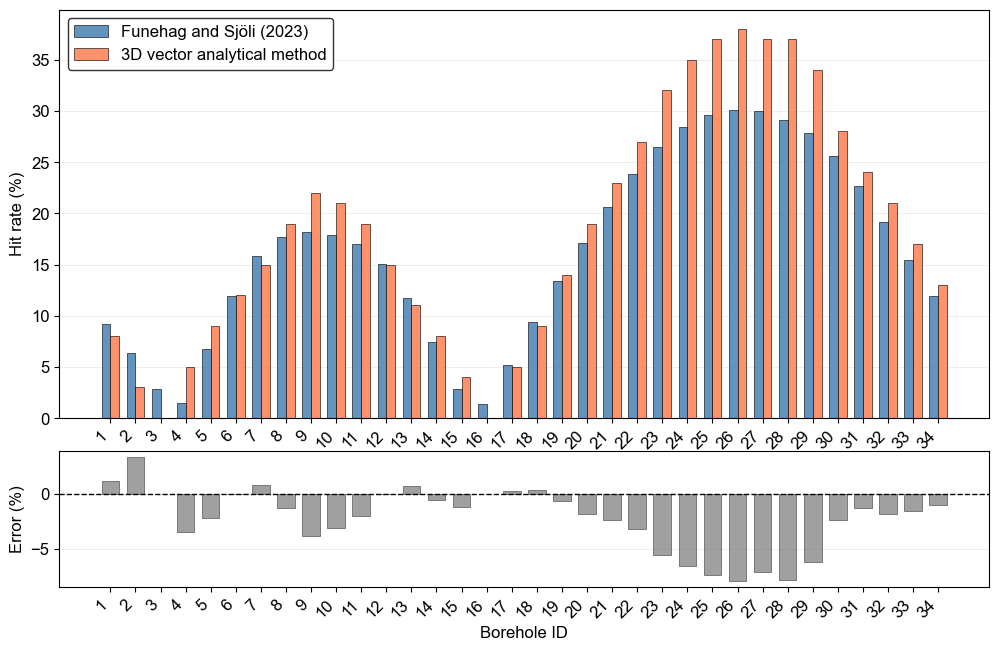

Saved to: C:\Users\abisheks\OneDrive - NTNU\Hit rate\Python\Hit_rate_Final_code\hit_rate_outputs


In [5]:
# =========================================================
# CELL 6 — SG-1 comparison
# =========================================================
sg1_paper = [8, 3, np.nan, 5, 9, 12, 15, 19, 22, 21, 19, 15, 11, 8, 4, np.nan,
             5, 9, 14, 19, 23, 27, 32, 35, 37, 38, 37, 37, 34, 28, 24, 21, 17, 13]

sg1_df = pd.DataFrame({"Hole": list(range(1, 35)), "SG1_hit_rate": sg1_paper})

result = pd.merge(result, sg1_df, on="Hole", how="left")

result["Error_vs_SG1"] = result["hit_rate"] - result["SG1_hit_rate"]
result["Abs_Error_vs_SG1"] = np.abs(result["Error_vs_SG1"])

valid = result["SG1_hit_rate"].notna()

mae = np.mean(result.loc[valid, "Abs_Error_vs_SG1"])
rmse = np.sqrt(np.mean(result.loc[valid, "Error_vs_SG1"]**2))

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
# =========================================================
# FIGURE 2 — SG-1 HIT-RATE COMPARISON + ERROR
# Save in same directory, Arial, font size 12, 900 DPI
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =========================================================
# 1. Plot settings
# =========================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

# Same output directory as before
out_dir = Path("hit_rate_outputs")
out_dir.mkdir(exist_ok=True)

# =========================================================
# 2. Figure setup
# =========================================================

fig2, (ax3, ax4) = plt.subplots(
    2,
    1,
    figsize=(12, 7.5),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
        "hspace": 0.12
    }
)

# Numeric x positions
labels = result["Hole"].astype(str).values
x = np.arange(len(labels))

bar_w = 0.35

# =========================================================
# 3. Top panel — hit-rate comparison
# =========================================================

ax3.bar(
    x - bar_w / 2,
    result["hit_rate"],
    width=bar_w,
    label="Funehag and Sjöli (2023)",
    color="steelblue",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

ax3.bar(
    x + bar_w / 2,
    result["SG1_hit_rate"],
    width=bar_w,
    label="3D vector analytical method",
    color="coral",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

ax3.set_ylabel("Hit rate (%)")
ax3.legend(frameon=True, edgecolor="black", loc="upper left")
ax3.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax3.set_axisbelow(True)

# Show x labels on top panel
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha="right")
ax3.tick_params(axis="x", labelbottom=True)

# =========================================================
# 4. Bottom panel — error
# =========================================================

ax4.bar(
    x,
    result["Error_vs_SG1"],
    width=0.70,
    color="gray",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4
)

ax4.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

ax4.set_xlabel("Borehole ID")
ax4.set_ylabel("Error (%)")
ax4.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax4.set_axisbelow(True)

ax4.set_xticks(x)
ax4.set_xticklabels(labels, rotation=45, ha="right")

# =========================================================
# 5. Save figure
# =========================================================

fig2.savefig(
    out_dir / "Figure_2_SG1_hit_rate_comparison_error.png",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.20
)

fig2.savefig(
    out_dir / "Figure_2_SG1_hit_rate_comparison_error.tiff",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.20
)

fig2.savefig(
    out_dir / "Figure_2_SG1_hit_rate_comparison_error.pdf",
    bbox_inches="tight",
    pad_inches=0.20
)

plt.show()

print(f"Saved to: {out_dir.resolve()}")

Hole 16T: psi change = 15.00°, optimized hit rate = 6.88%
Hole 17T: psi change = 15.00°, optimized hit rate = 11.89%

Summary
Original boreholes, all: 34
Original boreholes used for comparison: 33
Reoriented boreholes after removing 2T and adding 16T/17T: 18
Saved updated reoriented file: C:\Users\abisheks\OneDrive - NTNU\Hit rate\Python\Hit_rate_Final_code\hit_rate_outputs\hello_constrained_16T_17T_without_2T.xlsx
Mean original hit rate   = 18.13%
Mean reoriented hit rate = 21.41%


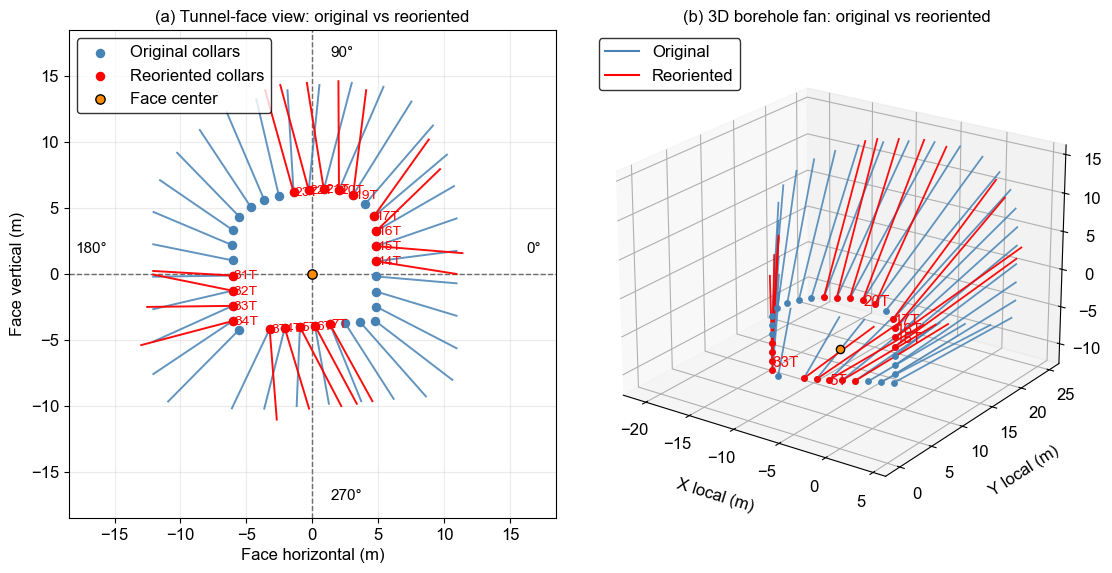


Publication table — local coordinates, beta and azimuth
   Original borehole Reoriented borehole  Original collar X_local (m)  \
0                  3                  3T                        -3.02   
1                  4                  4T                        -1.95   
2                  5                  5T                        -0.88   
3                  6                  6T                         0.18   
4                  7                  7T                         1.25   
5                 14                 14T                         4.52   
6                 15                 15T                         4.52   
7                 16                 16T                         4.52   
8                 17                 17T                         4.36   
9                 19                 19T                         2.88   
10                20                 20T                         1.88   
11                21                 21T                         0.

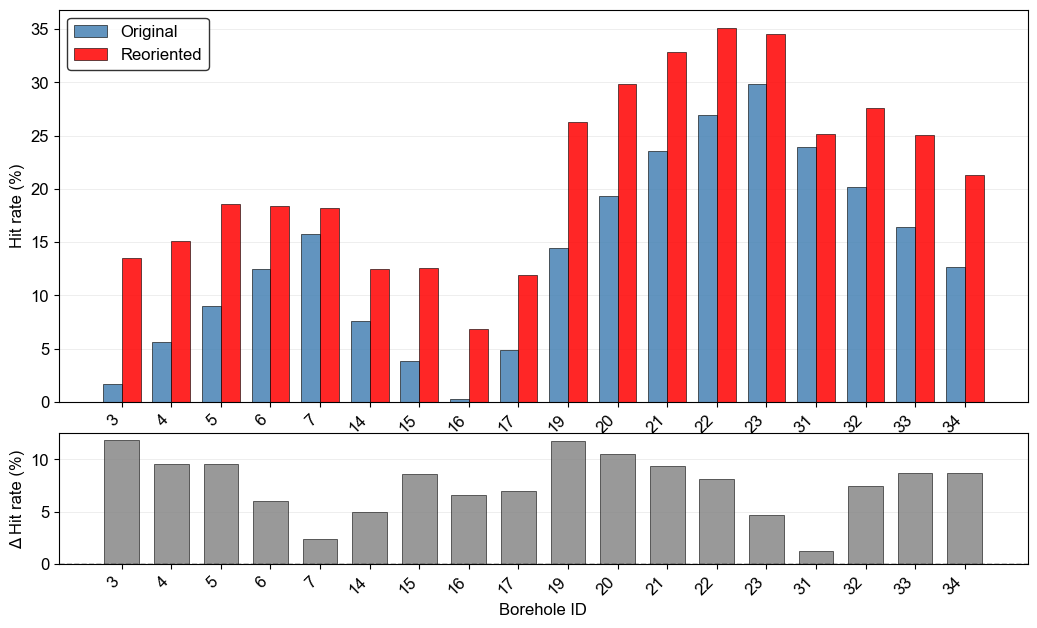


All outputs saved in: C:\Users\abisheks\OneDrive - NTNU\Hit rate\Python\Hit_rate_Final_code\hit_rate_outputs


In [6]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path

# =========================================================
# 1. Plot settings
# =========================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

out_dir = Path("hit_rate_outputs")
out_dir.mkdir(exist_ok=True)

# =========================================================
# 2. User input
# =========================================================

file_name_old = "Haga_original cordinates.xlsx"
file_name_new = "hello.xlsx"

# Tunnel alignment
AZt_deg = 340.0
PZt_deg = 0.0

# Tunnel-face center
center = np.array([1.47755153e+05, 6.39762933e+06, -1.80261765e+01])

# SG-1 orientation
ORIENTATION_TYPE = "strike_rhr"
sg1_orientation_deg = 165.0
sg1_dip_deg = 45.0

# Reorientation setup
holes_to_add = [16, 17]
remove_holes_new = ["2"]

# Constraint for 16T and 17T
max_psi_change_deg = 15.0
psi_step_deg = 0.25

# Colours
old_color = "steelblue"
new_color = "red"
face_center_color = "darkorange"

# Selected reoriented borehole labels in 3D
label_holes_3d = {5, 10, 15, 16, 17, 20, 25, 28, 30, 33}

# =========================================================
# 3. Helper functions
# =========================================================

def unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)

    if n == 0:
        raise ValueError("Zero-length vector encountered.")

    return v / n


def deg2rad(angle_deg):
    return math.radians(float(angle_deg))


def angle_diff_deg(new_angle, old_angle):
    return (new_angle - old_angle + 180.0) % 360.0 - 180.0


def normal_from_dipdir_dip(dipdir_deg, dip_deg):
    dipdir = deg2rad(dipdir_deg)
    dip = deg2rad(dip_deg)

    n = np.array([
        math.sin(dip) * math.sin(dipdir),
        math.sin(dip) * math.cos(dipdir),
        math.cos(dip)
    ])

    return unit(n)


def joint_normal_from_orientation(orientation_deg, dip_deg, orientation_type="strike_rhr"):
    if orientation_type == "strike_rhr":
        dipdir_deg = (orientation_deg + 90.0) % 360.0

    elif orientation_type == "dip_direction":
        dipdir_deg = orientation_deg % 360.0

    else:
        raise ValueError("orientation_type must be 'strike_rhr' or 'dip_direction'.")

    return normal_from_dipdir_dip(dipdir_deg, dip_deg)


def azimuth_plunge_from_vector(v):
    v = unit(v)

    az = math.degrees(math.atan2(v[0], v[1])) % 360.0
    plunge = -math.degrees(math.asin(v[2]))

    return az, plunge


def read_borehole_excel(file_name):
    df = pd.read_excel(file_name)
    df.columns = [c.strip() for c in df.columns]

    required_cols = ["Hole", "X_start", "Y_start", "Z_start", "X_end", "Y_end", "Z_end"]
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns in {file_name}: {missing}")

    num_cols = ["X_start", "Y_start", "Z_start", "X_end", "Y_end", "Z_end"]

    for col in num_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
            .astype(float)
        )

    if "Length" in df.columns:
        df["Length"] = (
            df["Length"]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
            .astype(float)
        )

    df["Hole"] = df["Hole"].astype(str).str.strip()
    df["Hole_base"] = df["Hole"].str.replace(r"T$", "", regex=True)

    df["Hole_num"] = pd.to_numeric(
        df["Hole_base"].str.extract(r"(\d+)", expand=False),
        errors="coerce"
    )

    df = df.sort_values("Hole_num").reset_index(drop=True)

    return df

# =========================================================
# 4. Tunnel coordinate system
# =========================================================

AZt = deg2rad(AZt_deg)
PZt = deg2rad(PZt_deg)

t = np.array([
    math.cos(PZt) * math.sin(AZt),
    math.cos(PZt) * math.cos(AZt),
    -math.sin(PZt)
])
t = unit(t)

t1 = np.array([
    math.cos(AZt),
    -math.sin(AZt),
    0.0
])
t1 = unit(t1)

t2 = np.cross(t1, t)
t2 = unit(t2)

sg1_normal = joint_normal_from_orientation(
    sg1_orientation_deg,
    sg1_dip_deg,
    ORIENTATION_TYPE
)

# =========================================================
# 5. Geometry and hit-rate calculation
# =========================================================

def compute_result(df_in):
    records = []

    for _, row in df_in.iterrows():
        start = np.array(
            [row["X_start"], row["Y_start"], row["Z_start"]],
            dtype=float
        )

        end = np.array(
            [row["X_end"], row["Y_end"], row["Z_end"]],
            dtype=float
        )

        coord_length = np.linalg.norm(end - start)

        if "Length" in row.index and pd.notna(row["Length"]):
            length_m = float(row["Length"])
        else:
            length_m = coord_length

        li = unit(end - start)

        if np.dot(li, t) < 0:
            li = -li

        cos_beta = np.clip(np.dot(li, t), -1.0, 1.0)
        beta_deg_calc = math.degrees(math.acos(cos_beta))

        p = start - center
        u1 = np.dot(p, t1)
        u2 = np.dot(p, t2)

        psi_face = math.atan2(u2, u1)
        psi_face_deg = (math.degrees(psi_face) + 360.0) % 360.0

        radial_component = li - np.dot(li, t) * t

        if np.linalg.norm(radial_component) > 1e-12:
            radial_component = unit(radial_component)

            psi_borehole = math.atan2(
                np.dot(radial_component, t2),
                np.dot(radial_component, t1)
            )

            psi_borehole_deg = (math.degrees(psi_borehole) + 360.0) % 360.0

        else:
            psi_borehole_deg = np.nan

        az_deg, plunge_deg = azimuth_plunge_from_vector(li)

        hit_rate_decimal = abs(np.dot(li, sg1_normal))
        hit_rate = hit_rate_decimal * 100.0

        records.append({
            "Hole": row["Hole"],
            "Hole_base": row["Hole_base"],
            "Hole_num": row["Hole_num"],

            "X_start": row["X_start"],
            "Y_start": row["Y_start"],
            "Z_start": row["Z_start"],
            "X_end": row["X_end"],
            "Y_end": row["Y_end"],
            "Z_end": row["Z_end"],

            "Length_m": length_m,
            "psi_face_deg": psi_face_deg,
            "psi_borehole_deg": psi_borehole_deg,
            "beta_deg_calc": beta_deg_calc,
            "Az_deg": az_deg,
            "Plunge_deg": plunge_deg,

            "l_x": li[0],
            "l_y": li[1],
            "l_z": li[2],

            "hit_rate": hit_rate
        })

    result_out = pd.DataFrame(records)
    result_out = result_out.sort_values("Hole_num").reset_index(drop=True)

    return result_out

# =========================================================
# 6. Constrained reorientation for 16T and 17T
# =========================================================

def constrained_reoriented_hole_from_original(row_old):
    start = np.array(
        [row_old["X_start"], row_old["Y_start"], row_old["Z_start"]],
        dtype=float
    )

    end_old = np.array(
        [row_old["X_end"], row_old["Y_end"], row_old["Z_end"]],
        dtype=float
    )

    coord_length = np.linalg.norm(end_old - start)

    if "Length" in row_old.index and pd.notna(row_old["Length"]):
        length_m = float(row_old["Length"])
    else:
        length_m = coord_length

    li_old = unit(end_old - start)

    if np.dot(li_old, t) < 0:
        li_old = -li_old

    beta_old = math.acos(
        np.clip(np.dot(li_old, t), -1.0, 1.0)
    )

    radial_old = li_old - np.dot(li_old, t) * t

    if np.linalg.norm(radial_old) < 1e-12:
        raise ValueError("Original borehole has no radial component.")

    radial_old = unit(radial_old)

    psi_old = math.atan2(
        np.dot(radial_old, t2),
        np.dot(radial_old, t1)
    )

    delta_values = np.arange(
        -max_psi_change_deg,
        max_psi_change_deg + psi_step_deg,
        psi_step_deg
    )

    best_hit = -np.inf
    best_li = None
    best_delta_deg = None

    for delta_deg in delta_values:
        psi_candidate = psi_old + math.radians(delta_deg)

        radial_candidate = (
            t1 * math.cos(psi_candidate)
            + t2 * math.sin(psi_candidate)
        )

        li_candidate = unit(
            t * math.cos(beta_old)
            + radial_candidate * math.sin(beta_old)
        )

        hit_candidate = abs(np.dot(li_candidate, sg1_normal)) * 100.0

        if hit_candidate > best_hit:
            best_hit = hit_candidate
            best_li = li_candidate
            best_delta_deg = delta_deg

    end_new = start + length_m * best_li

    new_row = row_old.copy()

    base = str(row_old["Hole_base"])
    new_row["Hole"] = f"{base}T"
    new_row["Hole_base"] = base
    new_row["Hole_num"] = float(base)

    new_row["X_end"] = end_new[0]
    new_row["Y_end"] = end_new[1]
    new_row["Z_end"] = end_new[2]

    if "Length" in new_row.index:
        new_row["Length"] = length_m

    print(
        f"Hole {base}T: psi change = {best_delta_deg:.2f}°, "
        f"optimized hit rate = {best_hit:.2f}%"
    )

    return new_row

# =========================================================
# 7. Read files, remove 2T, add 16T and 17T
# =========================================================

df_old = read_borehole_excel(file_name_old)
df_new = read_borehole_excel(file_name_new)

# Remove 2T
df_new = df_new[~df_new["Hole_base"].isin(remove_holes_new)].copy().reset_index(drop=True)

# Remove existing 16T and 17T before adding constrained versions
holes_to_add_str = [str(h) for h in holes_to_add]
df_new = df_new[~df_new["Hole_base"].isin(holes_to_add_str)].copy().reset_index(drop=True)

# Add constrained 16T and 17T
new_rows = []

for h in holes_to_add:
    h_str = str(h)

    old_match = df_old[df_old["Hole_base"] == h_str]

    if old_match.empty:
        raise ValueError(f"Could not find original borehole {h_str} in {file_name_old}")

    new_row = constrained_reoriented_hole_from_original(old_match.iloc[0])
    new_rows.append(new_row)

df_new_added = pd.concat(
    [df_new, pd.DataFrame(new_rows)],
    ignore_index=True
)

df_new_added["Hole_num"] = pd.to_numeric(
    df_new_added["Hole_base"].str.extract(r"(\d+)", expand=False),
    errors="coerce"
)

df_new_added = df_new_added.sort_values("Hole_num").reset_index(drop=True)

output_excel = out_dir / "hello_constrained_16T_17T_without_2T.xlsx"
df_new_added.to_excel(output_excel, index=False)

# Calculate results
result = compute_result(df_old)

# Remove original 2 to match removed 2T
result_for_compare = result[result["Hole_base"] != "2"].copy().reset_index(drop=True)

result_new = compute_result(df_new_added)
result_new_for_compare = result_new.copy().reset_index(drop=True)

result_for_compare.to_csv(
    out_dir / "Original_geometry_hit_rate_without_2.csv",
    index=False
)

result_new_for_compare.to_csv(
    out_dir / "Reoriented_geometry_hit_rate_constrained_16T_17T_without_2T.csv",
    index=False
)

print("\nSummary")
print("Original boreholes, all:", len(result))
print("Original boreholes used for comparison:", len(result_for_compare))
print("Reoriented boreholes after removing 2T and adding 16T/17T:", len(result_new_for_compare))
print(f"Saved updated reoriented file: {output_excel.resolve()}")
print(f"Mean original hit rate   = {result_for_compare['hit_rate'].mean():.2f}%")
print(f"Mean reoriented hit rate = {result_new_for_compare['hit_rate'].mean():.2f}%")

# =========================================================
# 8. FIGURE 3 — Original vs reoriented geometry
# Uses local coordinates in 3D to hide absolute coordinates
# =========================================================

S_old = result_for_compare[["X_start", "Y_start", "Z_start"]].to_numpy(dtype=float)
E_old = result_for_compare[["X_end", "Y_end", "Z_end"]].to_numpy(dtype=float)

S_new = result_new_for_compare[["X_start", "Y_start", "Z_start"]].to_numpy(dtype=float)
E_new = result_new_for_compare[["X_end", "Y_end", "Z_end"]].to_numpy(dtype=float)

C = center.copy()

# Face plane from original collars
Xc = S_old - C
_, _, VT = np.linalg.svd(Xc, full_matrices=False)
n_face = VT[-1, :]

up = np.array([0.0, 0.0, 1.0])
y_axis = up - np.dot(up, n_face) * n_face
y_axis /= np.linalg.norm(y_axis)

x_axis = np.cross(y_axis, n_face)
x_axis /= np.linalg.norm(x_axis)

def proj2(P):
    Q = P - C
    return np.column_stack([Q @ x_axis, Q @ y_axis])

S2_old = proj2(S_old)
E2_old = proj2(E_old)
S2_new = proj2(S_new)
E2_new = proj2(E_new)

# Local 3D coordinates
S_old_local = S_old - C
E_old_local = E_old - C
S_new_local = S_new - C
E_new_local = E_new - C

fig3 = plt.figure(figsize=(15.0, 6.5))

# -------------------------
# 8a. Face view
# -------------------------

ax1 = fig3.add_subplot(1, 2, 1)

for (x0, y0), (x1, y1) in zip(S2_old, E2_old):
    ax1.plot(
        [x0, x1],
        [y0, y1],
        color=old_color,
        linewidth=1.4,
        alpha=0.85,
        zorder=2
    )

for (x0, y0), (x1, y1) in zip(S2_new, E2_new):
    ax1.plot(
        [x0, x1],
        [y0, y1],
        color=new_color,
        linewidth=1.4,
        alpha=0.95,
        zorder=3
    )

ax1.scatter(
    S2_old[:, 0],
    S2_old[:, 1],
    s=34,
    color=old_color,
    label="Original collars",
    zorder=4
)

ax1.scatter(
    S2_new[:, 0],
    S2_new[:, 1],
    s=34,
    color=new_color,
    label="Reoriented collars",
    zorder=5
)

ax1.scatter(
    0,
    0,
    s=45,
    color=face_center_color,
    edgecolor="black",
    label="Face center",
    zorder=6
)

for (x0, y0), lab in zip(S2_new, result_new_for_compare["Hole"]):
    ax1.text(
        x0 + 0.10,
        y0 - 0.28,
        str(lab),
        color=new_color,
        fontsize=10,
        zorder=7
    )

all_2d = np.vstack([S2_old, E2_old, S2_new, E2_new])
lim_ref = np.max(np.abs(all_2d)) * 1.15
pad = lim_ref * 0.10

ax1.set_xlim(-lim_ref - pad, lim_ref + pad)
ax1.set_ylim(-lim_ref - pad, lim_ref + pad)

ax1.axhline(0, linestyle="--", linewidth=1.0, color="0.35", zorder=1)
ax1.axvline(0, linestyle="--", linewidth=1.0, color="0.35", zorder=1)

label_offset = lim_ref * 0.08

ax1.text(lim_ref, label_offset, "0°", ha="center", va="bottom", fontsize=11)
ax1.text(label_offset, lim_ref, "90°", ha="left", va="center", fontsize=11)
ax1.text(-lim_ref, label_offset, "180°", ha="center", va="bottom", fontsize=11)
ax1.text(label_offset, -lim_ref, "270°", ha="left", va="center", fontsize=11)

ax1.set_title("(a) Tunnel-face view: original vs reoriented")
ax1.set_xlabel("Face horizontal (m)")
ax1.set_ylabel("Face vertical (m)")
ax1.set_aspect("equal", adjustable="box")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True, edgecolor="black", loc="upper left")

# -------------------------
# 8b. 3D local-coordinate view
# -------------------------

ax2 = fig3.add_subplot(1, 2, 2, projection="3d")

for s, e in zip(S_old_local, E_old_local):
    ax2.plot(
        [s[0], e[0]],
        [s[1], e[1]],
        [s[2], e[2]],
        color=old_color,
        linewidth=1.3,
        alpha=0.85
    )

    ax2.scatter(
        s[0],
        s[1],
        s[2],
        color=old_color,
        s=15
    )

for s, e in zip(S_new_local, E_new_local):
    ax2.plot(
        [s[0], e[0]],
        [s[1], e[1]],
        [s[2], e[2]],
        color=new_color,
        linewidth=1.3,
        alpha=0.95
    )

    ax2.scatter(
        s[0],
        s[1],
        s[2],
        color=new_color,
        s=15
    )

ax2.scatter(
    0,
    0,
    0,
    color=face_center_color,
    edgecolor="black",
    s=35
)

for idx, row in result_new_for_compare.iterrows():
    hnum = int(row["Hole_num"])

    if hnum in label_holes_3d:
        s = S_new_local[idx]

        ax2.text(
            s[0] + 0.3,
            s[1] - 0.4,
            s[2] - 0.4,
            str(row["Hole"]),
            fontsize=11,
            color=new_color
        )

ax2.plot([], [], [], color=old_color, label="Original")
ax2.plot([], [], [], color=new_color, label="Reoriented")

ax2.set_title("(b) 3D borehole fan: original vs reoriented")
ax2.set_xlabel("X local (m)", labelpad=12)
ax2.set_ylabel("Y local (m)", labelpad=12)
ax2.set_zlabel("Z local (m)", labelpad=32)

ax2.view_init(elev=22, azim=-55)
ax2.legend(frameon=True, edgecolor="black", loc="upper left")

all_xyz_local = np.vstack([
    S_old_local,
    E_old_local,
    S_new_local,
    E_new_local,
    np.array([[0.0, 0.0, 0.0]])
])

x_limits = [all_xyz_local[:, 0].min(), all_xyz_local[:, 0].max()]
y_limits = [all_xyz_local[:, 1].min(), all_xyz_local[:, 1].max()]
z_limits = [all_xyz_local[:, 2].min(), all_xyz_local[:, 2].max()]

max_range = max(
    x_limits[1] - x_limits[0],
    y_limits[1] - y_limits[0],
    z_limits[1] - z_limits[0]
)

x_mid = np.mean(x_limits)
y_mid = np.mean(y_limits)
z_mid = np.mean(z_limits)

ax2.set_xlim(x_mid - max_range / 2, x_mid + max_range / 2)
ax2.set_ylim(y_mid - max_range / 2, y_mid + max_range / 2)
ax2.set_zlim(z_mid - max_range / 2, z_mid + max_range / 2)

ax1.set_position([0.06, 0.13, 0.38, 0.75])
ax2.set_position([0.43, 0.12, 0.34, 0.76])

fig3.savefig(
    out_dir / "Figure_3_Original_vs_Reoriented_LocalCoordinates.png",
    dpi=900
)

fig3.savefig(
    out_dir / "Figure_3_Original_vs_Reoriented_LocalCoordinates.tiff",
    dpi=900
)

fig3.savefig(
    out_dir / "Figure_3_Original_vs_Reoriented_LocalCoordinates.pdf"
)

plt.show()

# =========================================================
# 9. TABLE — Local coordinates, beta and azimuth
# Hit rate is excluded because it is shown in Figure 4
# =========================================================

old_keep = [
    "Hole", "Hole_base", "Hole_num",
    "X_start", "Y_start", "Z_start",
    "X_end", "Y_end", "Z_end",
    "beta_deg_calc",
    "Az_deg"
]

new_keep = [
    "Hole", "Hole_base",
    "X_start", "Y_start", "Z_start",
    "X_end", "Y_end", "Z_end",
    "beta_deg_calc",
    "Az_deg"
]

old_table = result_for_compare[old_keep].copy()
new_table = result_new_for_compare[new_keep].copy()

old_table = old_table.rename(columns={
    "Hole": "Hole_old",
    "X_start": "X_start_old",
    "Y_start": "Y_start_old",
    "Z_start": "Z_start_old",
    "X_end": "X_end_old",
    "Y_end": "Y_end_old",
    "Z_end": "Z_end_old",
    "beta_deg_calc": "beta_old",
    "Az_deg": "azimuth_old"
})

new_table = new_table.rename(columns={
    "Hole": "Hole_new",
    "X_start": "X_start_new",
    "Y_start": "Y_start_new",
    "Z_start": "Z_start_new",
    "X_end": "X_end_new",
    "Y_end": "Y_end_new",
    "Z_end": "Z_end_new",
    "beta_deg_calc": "beta_new",
    "Az_deg": "azimuth_new"
})

param_compare = pd.merge(
    old_table,
    new_table,
    on="Hole_base",
    how="inner"
)

param_compare = param_compare.sort_values("Hole_num").reset_index(drop=True)

cx, cy, cz = center[0], center[1], center[2]

# Original local coordinates
param_compare["Original collar X_local (m)"] = param_compare["X_start_old"] - cx
param_compare["Original collar Y_local (m)"] = param_compare["Y_start_old"] - cy
param_compare["Original collar Z_local (m)"] = param_compare["Z_start_old"] - cz

param_compare["Original end X_local (m)"] = param_compare["X_end_old"] - cx
param_compare["Original end Y_local (m)"] = param_compare["Y_end_old"] - cy
param_compare["Original end Z_local (m)"] = param_compare["Z_end_old"] - cz

# Reoriented local coordinates
param_compare["Reoriented collar X_local (m)"] = param_compare["X_start_new"] - cx
param_compare["Reoriented collar Y_local (m)"] = param_compare["Y_start_new"] - cy
param_compare["Reoriented collar Z_local (m)"] = param_compare["Z_start_new"] - cz

param_compare["Reoriented end X_local (m)"] = param_compare["X_end_new"] - cx
param_compare["Reoriented end Y_local (m)"] = param_compare["Y_end_new"] - cy
param_compare["Reoriented end Z_local (m)"] = param_compare["Z_end_new"] - cz

# Changes
param_compare["Endpoint shift (m)"] = np.sqrt(
    (param_compare["X_end_new"] - param_compare["X_end_old"])**2 +
    (param_compare["Y_end_new"] - param_compare["Y_end_old"])**2 +
    (param_compare["Z_end_new"] - param_compare["Z_end_old"])**2
)

param_compare["Delta beta (deg)"] = (
    param_compare["beta_new"] -
    param_compare["beta_old"]
)

param_compare["Delta azimuth (deg)"] = angle_diff_deg(
    param_compare["azimuth_new"],
    param_compare["azimuth_old"]
)

publication_table = param_compare[[
    "Hole_old",
    "Hole_new",

    "Original collar X_local (m)",
    "Original collar Y_local (m)",
    "Original collar Z_local (m)",
    "Original end X_local (m)",
    "Original end Y_local (m)",
    "Original end Z_local (m)",

    "Reoriented collar X_local (m)",
    "Reoriented collar Y_local (m)",
    "Reoriented collar Z_local (m)",
    "Reoriented end X_local (m)",
    "Reoriented end Y_local (m)",
    "Reoriented end Z_local (m)",

    "Endpoint shift (m)",

    "beta_old",
    "beta_new",
    "Delta beta (deg)",

    "azimuth_old",
    "azimuth_new",
    "Delta azimuth (deg)"
]].copy()

publication_table = publication_table.rename(columns={
    "Hole_old": "Original borehole",
    "Hole_new": "Reoriented borehole",
    "beta_old": "Original beta (deg)",
    "beta_new": "Reoriented beta (deg)",
    "azimuth_old": "Original azimuth (deg)",
    "azimuth_new": "Reoriented azimuth (deg)"
})

publication_table = publication_table.round(2)

publication_table.to_csv(
    out_dir / "Table_Reorientation_Local_Coordinates_Beta_Azimuth.csv",
    index=False
)

publication_table.to_excel(
    out_dir / "Table_Reorientation_Local_Coordinates_Beta_Azimuth.xlsx",
    index=False
)

print("\nPublication table — local coordinates, beta and azimuth")
print(publication_table)

# =========================================================
# 10. FIGURE 4 — Hit-rate comparison
# =========================================================

hit_table_old = result_for_compare[[
    "Hole_base", "Hole_num", "hit_rate"
]].rename(columns={
    "hit_rate": "hit_rate_old"
})

hit_table_new = result_new_for_compare[[
    "Hole_base", "hit_rate"
]].rename(columns={
    "hit_rate": "hit_rate_new"
})

hit_compare = pd.merge(
    hit_table_old,
    hit_table_new,
    on="Hole_base",
    how="inner"
)

hit_compare = hit_compare.sort_values("Hole_num").reset_index(drop=True)

hit_compare["dHit_rate_percent"] = (
    hit_compare["hit_rate_new"] -
    hit_compare["hit_rate_old"]
)

x_pos = np.arange(len(hit_compare))
labels = hit_compare["Hole_num"].astype(int).astype(str).values
bar_w = 0.38

fig4, (ax3, ax4) = plt.subplots(
    2,
    1,
    figsize=(12.5, 7.2),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
        "hspace": 0.12
    }
)

ax3.bar(
    x_pos - bar_w / 2,
    hit_compare["hit_rate_old"].values,
    width=bar_w,
    color=old_color,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
    label="Original"
)

ax3.bar(
    x_pos + bar_w / 2,
    hit_compare["hit_rate_new"].values,
    width=bar_w,
    color=new_color,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85,
    label="Reoriented"
)

ax3.set_ylabel("Hit rate (%)")
ax3.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax3.set_axisbelow(True)
ax3.legend(frameon=True, edgecolor="black", loc="upper left")

ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels, rotation=45, ha="right")
ax3.tick_params(axis="x", labelbottom=True)

ax4.bar(
    x_pos,
    hit_compare["dHit_rate_percent"].values,
    width=0.70,
    color="gray",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.80
)

ax4.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

ax4.set_ylabel("Δ Hit rate (%)")
ax4.set_xlabel("Borehole ID")
ax4.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax4.set_axisbelow(True)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(labels, rotation=45, ha="right")

fig4.savefig(
    out_dir / "Figure_4_HitRate_Constrained_Reorientation.png",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.20
)

fig4.savefig(
    out_dir / "Figure_4_HitRate_Constrained_Reorientation.tiff",
    dpi=900,
    bbox_inches="tight",
    pad_inches=0.20
)

fig4.savefig(
    out_dir / "Figure_4_HitRate_Constrained_Reorientation.pdf",
    bbox_inches="tight",
    pad_inches=0.20
)

plt.show()

print(f"\nAll outputs saved in: {out_dir.resolve()}")

In [7]:
# =========================================================
# CELL — Calculate SG-2 and SG-3 hit rate + spacing sensitivity
#
# Run this after your reorientation code, so these already exist:
# - result_for_compare
# - result_new_for_compare
#
# This creates:
# - hit_long
# - spacing_long
#
# These are needed for the four-panel figure:
# a) SG-1 original
# b) SG-1 reoriented
# c) SG-2 original
# d) SG-3 original
# =========================================================

import numpy as np
import pandas as pd
import math
from pathlib import Path

out_dir = Path("hit_rate_outputs")
out_dir.mkdir(exist_ok=True)

# =========================================================
# 1. Joint sets for SG-2 and SG-3
# =========================================================

ORIENTATION_TYPE = "strike_rhr"

joint_sets_sg23 = pd.DataFrame({
    "Joint_set": ["SG-2", "SG-3"],
    "Orientation_deg": [80.0, 305.0],
    "Dip_deg": [90.0, 55.0]
})

spacing_values = [0.5, 1.0, 1.5, 3.0, 5.0]

# =========================================================
# 2. Helper functions
# =========================================================

def unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)

    if n == 0:
        raise ValueError("Zero-length vector encountered.")

    return v / n


def deg2rad(angle_deg):
    return math.radians(float(angle_deg))


def normal_from_dipdir_dip(dipdir_deg, dip_deg):
    """
    Unit normal vector from dip direction and dip.
    Coordinate system:
    X = East, Y = North, Z = Up.
    """
    dipdir = deg2rad(dipdir_deg)
    dip = deg2rad(dip_deg)

    n = np.array([
        math.sin(dip) * math.sin(dipdir),
        math.sin(dip) * math.cos(dipdir),
        math.cos(dip)
    ])

    return unit(n)


def joint_normal_from_orientation(orientation_deg, dip_deg, orientation_type="strike_rhr"):
    """
    If orientation_type = strike_rhr:
        orientation_deg is strike using right-hand rule.
        dip direction = strike + 90°.

    If orientation_type = dip_direction:
        orientation_deg is dip direction.
    """
    if orientation_type == "strike_rhr":
        dipdir_deg = (orientation_deg + 90.0) % 360.0

    elif orientation_type == "dip_direction":
        dipdir_deg = orientation_deg % 360.0

    else:
        raise ValueError("orientation_type must be 'strike_rhr' or 'dip_direction'.")

    return normal_from_dipdir_dip(dipdir_deg, dip_deg)


def clean_hole_label(value):
    text = str(value).strip()
    text = text.replace("T", "")

    if text.endswith(".0"):
        text = text[:-2]

    return text


# =========================================================
# 3. Prepare original borehole geometry for SG-2 and SG-3
# =========================================================

bh_original = result_for_compare.copy()

bh_original["Hole_label"] = bh_original["Hole_base"].apply(clean_hole_label)

# Make sure Length_m exists
if "Length_m" not in bh_original.columns:
    bh_original["Length_m"] = np.sqrt(
        (bh_original["X_end"] - bh_original["X_start"])**2 +
        (bh_original["Y_end"] - bh_original["Y_start"])**2 +
        (bh_original["Z_end"] - bh_original["Z_start"])**2
    )

# Make sure borehole vector columns exist
if not {"l_x", "l_y", "l_z"}.issubset(bh_original.columns):
    vectors = []

    for _, row in bh_original.iterrows():
        start = np.array(
            [row["X_start"], row["Y_start"], row["Z_start"]],
            dtype=float
        )

        end = np.array(
            [row["X_end"], row["Y_end"], row["Z_end"]],
            dtype=float
        )

        li = unit(end - start)

        vectors.append(li)

    vectors = np.array(vectors)

    bh_original["l_x"] = vectors[:, 0]
    bh_original["l_y"] = vectors[:, 1]
    bh_original["l_z"] = vectors[:, 2]

# =========================================================
# 4. Calculate hit_long for SG-2 and SG-3
# =========================================================

hit_records = []

for _, bh in bh_original.iterrows():
    li = np.array([bh["l_x"], bh["l_y"], bh["l_z"]], dtype=float)
    li = unit(li)

    for _, js in joint_sets_sg23.iterrows():
        nj = joint_normal_from_orientation(
            js["Orientation_deg"],
            js["Dip_deg"],
            ORIENTATION_TYPE
        )

        h_decimal = abs(np.dot(li, nj))
        h_percent = h_decimal * 100.0

        hit_records.append({
            "Hole": bh["Hole"],
            "Hole_label": bh["Hole_label"],
            "Joint_set": js["Joint_set"],
            "Orientation_deg": js["Orientation_deg"],
            "Dip_deg": js["Dip_deg"],
            "Length_m": bh["Length_m"],
            "Hit_rate_decimal": h_decimal,
            "Hit_rate_percent": h_percent
        })

hit_long = pd.DataFrame(hit_records)

# =========================================================
# 5. Calculate spacing_long for SG-2 and SG-3
# =========================================================

spacing_records = []

for _, row in hit_long.iterrows():
    for spacing in spacing_values:
        expected_intersections = (
            row["Length_m"] *
            row["Hit_rate_decimal"] /
            spacing
        )

        spacing_records.append({
            "Hole": row["Hole"],
            "Hole_label": row["Hole_label"],
            "Joint_set": row["Joint_set"],
            "Spacing_m": spacing,
            "Length_m": row["Length_m"],
            "Hit_rate_percent": row["Hit_rate_percent"],
            "Expected_intersections": expected_intersections
        })

spacing_long = pd.DataFrame(spacing_records)

# =========================================================
# 6. Save outputs
# =========================================================

hit_long.to_csv(
    out_dir / "hit_rate_long_SG2_SG3_original.csv",
    index=False
)

spacing_long.to_csv(
    out_dir / "spacing_sensitivity_long_SG2_SG3_original.csv",
    index=False
)

hit_matrix_sg23 = (
    hit_long
    .pivot(index="Hole_label", columns="Joint_set", values="Hit_rate_percent")
)

hit_matrix_sg23.to_csv(
    out_dir / "hit_rate_matrix_SG2_SG3_original.csv"
)

print("\nSG-2 and SG-3 hit-rate matrix (%):")
print(hit_matrix_sg23.round(2))

print("\nCreated variables:")
print("hit_long")
print("spacing_long")

print(f"\nSaved outputs in: {out_dir.resolve()}")


SG-2 and SG-3 hit-rate matrix (%):
Joint_set    SG-2   SG-3
Hole_label              
1           89.47  16.82
10          98.35  49.19
11          99.09  53.14
12          99.60  56.40
13          99.85  59.56
14          99.82  62.55
15          99.53  65.35
16          99.00  67.54
17          98.26  69.12
18          97.26  70.44
19          96.13  70.68
20          95.14  69.41
21          94.41  66.80
22          93.81  63.37
23          93.16  59.62
24          92.47  55.51
25          91.85  51.16
26          91.33  46.68
27          90.95  42.26
28          90.37  37.69
29          90.21  33.63
3           92.42  22.56
30          90.51  30.70
31          90.61  27.73
32          90.47  24.69
33          90.09  21.62
34          89.45  18.48
4           93.76  25.97
5           95.04  29.83
6           96.05  33.58
7           96.80  37.27
8           97.28  40.79
9           97.51  44.19

Created variables:
hit_long
spacing_long

Saved outputs in: C:\Users\abisheks\OneDrive -

Number of holes shown: 34
Hole order: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34']
Reoriented holes shown in red: ['3', '4', '5', '6', '7', '14', '15', '16', '17', '19', '20', '21', '22', '23', '31', '32', '33', '34']


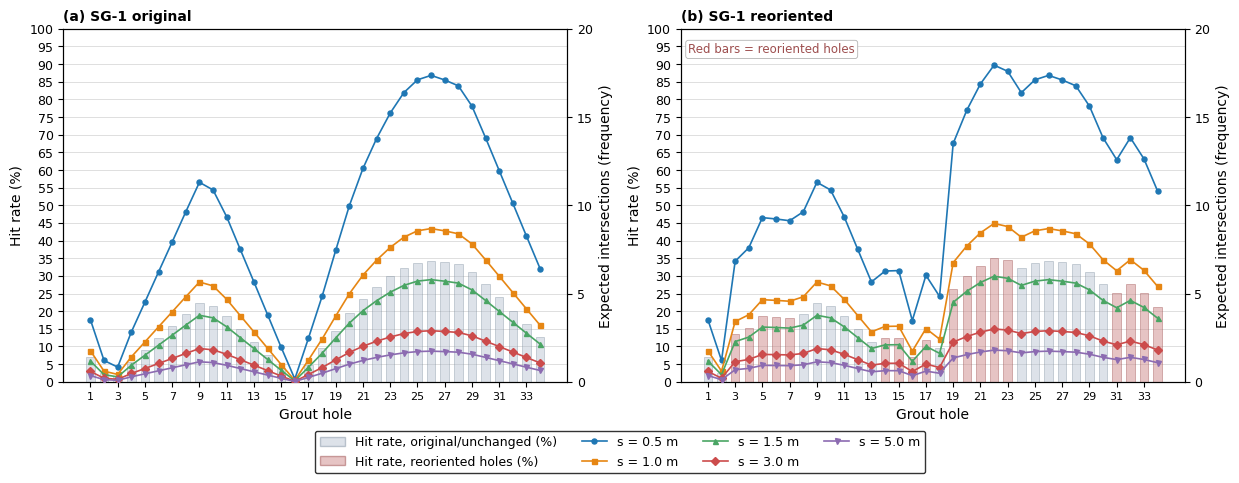

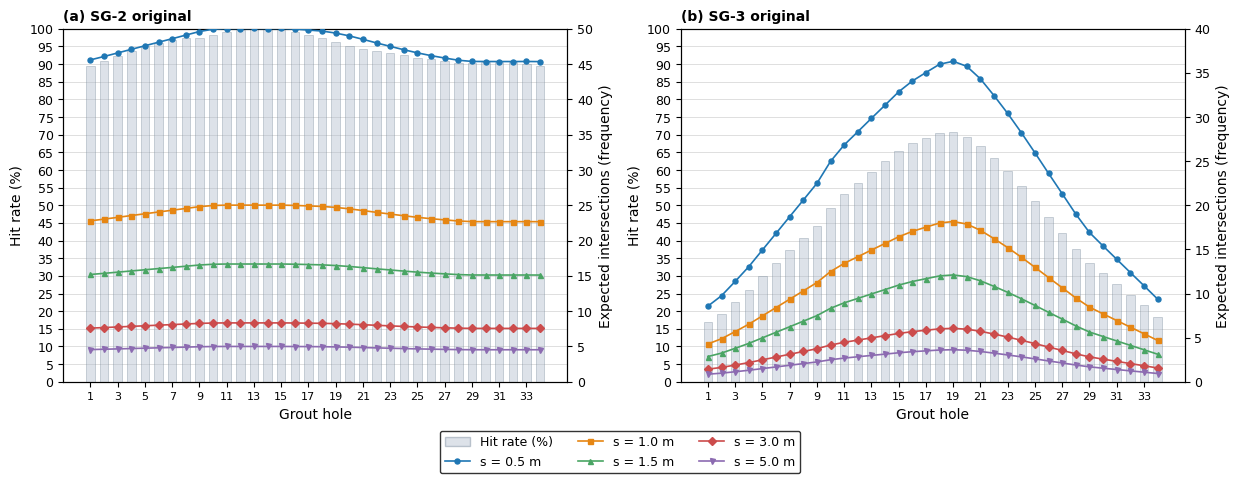


Saved publication figures in: C:\Users\abisheks\OneDrive - NTNU\Hit rate\Python\Hit_rate_Final_code\publication_figures_split_final


In [8]:
# =========================================================
# PUBLICATION FIGURES — split into TWO figures
#
# Figure 1:
#   (a) SG-1 original
#   (b) SG-1 reoriented
#
# Figure 2:
#   (a) SG-2 original
#   (b) SG-3 original
#
# Final changes:
# - Left y-axis  : Hit rate (%)
# - Right y-axis : Expected intersections (frequency)
# - Darker bars for hit rate
# - Right-axis frequency ticks at 5, 10, 15, ...
# - Reduced x-axis clutter
# - Hit rate axis ticks at intervals of 5
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# =========================================================
# 1. Output folder and publication style
# =========================================================
out_dir = Path("publication_figures_split_final")
out_dir.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8
plt.rcParams["xtick.major.size"] = 3.5
plt.rcParams["ytick.major.size"] = 3.5

# =========================================================
# 2. Settings
# =========================================================
spacing_order = [0.5, 1.0, 1.5, 3.0, 5.0]

marker_map = {
    0.5: "o",
    1.0: "s",
    1.5: "^",
    3.0: "D",
    5.0: "v"
}

line_color_map = {
    0.5: "#1f77b4",
    1.0: "#e68613",
    1.5: "#4aa564",
    3.0: "#cc4c4c",
    5.0: "#8c6bb1"
}

# Darker bars for hit rate
bar_color_original = "#AEBBCB"
bar_edge_original = "#6F8095"

bar_color_reoriented = "#CF8A8A"
bar_edge_reoriented = "#9E4F4F"

alpha_original = 0.42
alpha_reoriented = 0.50

line_width = 1.2
marker_size = 3.6
bar_width = 0.62

ORIENTATION_TYPE = "strike_rhr"

joint_sets_all = pd.DataFrame({
    "Joint_set": ["SG-1", "SG-2", "SG-3"],
    "Orientation_deg": [165.0, 80.0, 305.0],
    "Dip_deg": [45.0, 90.0, 55.0]
})

panel_titles = {
    "SG-1 original": "(a) SG-1 original",
    "SG-1 reoriented": "(b) SG-1 reoriented",
    "SG-2": "(a) SG-2 original",
    "SG-3": "(b) SG-3 original"
}

# Right-axis style for expected intersections (frequency)
# Use 5-unit intervals for all panels
panel_axis_style = {
    "SG-1 original":   {"ylim_right": (0, 20), "major_right": 5},
    "SG-1 reoriented": {"ylim_right": (0, 20), "major_right": 5},
    "SG-2":            {"ylim_right": (0, 50), "major_right": 5},
    "SG-3":            {"ylim_right": (0, 40), "major_right": 5},
}

# =========================================================
# 3. Helper functions
# =========================================================
def clean_hole_label(value):
    text = str(value).strip()
    text = text.replace("T", "")
    if text.endswith(".0"):
        text = text[:-2]
    return text


def hole_sort_key(value):
    text = clean_hole_label(value)
    try:
        return int(text)
    except ValueError:
        return text


def unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero-length vector encountered.")
    return v / n


def deg2rad(angle_deg):
    return math.radians(float(angle_deg))


def normal_from_dipdir_dip(dipdir_deg, dip_deg):
    dipdir = deg2rad(dipdir_deg)
    dip = deg2rad(dip_deg)

    n = np.array([
        math.sin(dip) * math.sin(dipdir),
        math.sin(dip) * math.cos(dipdir),
        math.cos(dip)
    ])
    return unit(n)


def joint_normal_from_orientation(orientation_deg, dip_deg, orientation_type="strike_rhr"):
    if orientation_type == "strike_rhr":
        dipdir_deg = (orientation_deg + 90.0) % 360.0
    elif orientation_type == "dip_direction":
        dipdir_deg = orientation_deg % 360.0
    else:
        raise ValueError("orientation_type must be 'strike_rhr' or 'dip_direction'.")
    return normal_from_dipdir_dip(dipdir_deg, dip_deg)


def ensure_length_and_vectors(df_in):
    df_out = df_in.copy()

    df_out["Hole_label"] = df_out["Hole_base"].apply(clean_hole_label)

    if "Length_m" not in df_out.columns:
        df_out["Length_m"] = np.sqrt(
            (df_out["X_end"] - df_out["X_start"])**2 +
            (df_out["Y_end"] - df_out["Y_start"])**2 +
            (df_out["Z_end"] - df_out["Z_start"])**2
        )

    if not {"l_x", "l_y", "l_z"}.issubset(df_out.columns):
        vectors = []

        for _, row in df_out.iterrows():
            start = np.array([row["X_start"], row["Y_start"], row["Z_start"]], dtype=float)
            end = np.array([row["X_end"], row["Y_end"], row["Z_end"]], dtype=float)
            li = unit(end - start)
            vectors.append(li)

        vectors = np.array(vectors)
        df_out["l_x"] = vectors[:, 0]
        df_out["l_y"] = vectors[:, 1]
        df_out["l_z"] = vectors[:, 2]

    return df_out


def calculate_hit_and_spacing_for_joint(result_df, joint_name, panel_name):
    temp = ensure_length_and_vectors(result_df)

    js = joint_sets_all[joint_sets_all["Joint_set"] == joint_name].iloc[0]

    nj = joint_normal_from_orientation(
        js["Orientation_deg"],
        js["Dip_deg"],
        ORIENTATION_TYPE
    )

    hit_records = []
    spacing_records = []

    for _, row in temp.iterrows():
        li = np.array([row["l_x"], row["l_y"], row["l_z"]], dtype=float)
        li = unit(li)

        hit_decimal = abs(np.dot(li, nj))
        hit_percent = hit_decimal * 100.0

        hole_label = clean_hole_label(row["Hole_base"])

        hit_records.append({
            "Hole_label": hole_label,
            "Panel": panel_name,
            "Hit_rate_percent": hit_percent
        })

        for spacing in spacing_order:
            expected_intersections = row["Length_m"] * hit_decimal / spacing

            spacing_records.append({
                "Hole_label": hole_label,
                "Panel": panel_name,
                "Spacing_m": spacing,
                "Expected_intersections": expected_intersections
            })

    hit_df = pd.DataFrame(hit_records)
    spacing_df = pd.DataFrame(spacing_records)

    return hit_df, spacing_df


def get_tick_positions_labels(hole_order, step=2):
    idx = np.arange(0, len(hole_order), step)
    labels = [hole_order[i] for i in idx]
    return idx, labels


# =========================================================
# 4. Prepare all-hole original dataset
# =========================================================
# IMPORTANT: 'result' must be a DataFrame with columns:
#   Hole_base, X_start, Y_start, Z_start, X_end, Y_end, Z_end
# (and optionally Length_m, l_x, l_y, l_z)
result_all_original = result.copy()
result_all_original["Hole_base"] = result_all_original["Hole_base"].astype(str).str.strip()
result_all_original["Hole_label"] = result_all_original["Hole_base"].apply(clean_hole_label)

# =========================================================
# 5. Prepare all-hole SG-1 reoriented dataset
# =========================================================
result_all_reoriented = result_all_original.copy()

# IMPORTANT: 'result_new_for_compare' must contain the reoriented hole data
# with columns: Hole_base, Hole, X_start, Y_start, Z_start, X_end, Y_end, Z_end,
# Length_m, l_x, l_y, l_z, hit_rate (optional)
result_new_temp = result_new_for_compare.copy()
result_new_temp["Hole_base"] = result_new_temp["Hole_base"].astype(str).str.strip()
result_new_temp["Hole_label"] = result_new_temp["Hole_base"].apply(clean_hole_label)

reoriented_holes = set(
    result_new_temp.loc[
        result_new_temp["Hole"].astype(str).str.endswith("T"),
        "Hole_base"
    ].astype(str)
)

replace_cols = [
    "Hole",
    "X_start", "Y_start", "Z_start",
    "X_end", "Y_end", "Z_end",
    "Length_m",
    "l_x", "l_y", "l_z",
    "hit_rate"
]

for hole_base in result_new_temp["Hole_base"].unique():
    new_row = result_new_temp[result_new_temp["Hole_base"] == hole_base].iloc[0]
    mask = result_all_reoriented["Hole_base"] == hole_base

    if mask.any():
        for col in replace_cols:
            if col in result_all_reoriented.columns and col in result_new_temp.columns:
                result_all_reoriented.loc[mask, col] = new_row[col]

result_all_reoriented["Hole_label"] = result_all_reoriented["Hole_base"].apply(clean_hole_label)

# =========================================================
# 6. Calculate panel data
# =========================================================
hit_sg1_original, spacing_sg1_original = calculate_hit_and_spacing_for_joint(
    result_all_original, "SG-1", "SG-1 original"
)

hit_sg1_reoriented, spacing_sg1_reoriented = calculate_hit_and_spacing_for_joint(
    result_all_reoriented, "SG-1", "SG-1 reoriented"
)

hit_sg2, spacing_sg2 = calculate_hit_and_spacing_for_joint(
    result_all_original, "SG-2", "SG-2"
)

hit_sg3, spacing_sg3 = calculate_hit_and_spacing_for_joint(
    result_all_original, "SG-3", "SG-3"
)

hit_plot = pd.concat(
    [hit_sg1_original, hit_sg1_reoriented, hit_sg2, hit_sg3],
    ignore_index=True
)

spacing_plot = pd.concat(
    [spacing_sg1_original, spacing_sg1_reoriented, spacing_sg2, spacing_sg3],
    ignore_index=True
)

hole_order = sorted(result_all_original["Hole_label"].unique(), key=hole_sort_key)

hit_plot = hit_plot[hit_plot["Hole_label"].isin(hole_order)].copy()
spacing_plot = spacing_plot[spacing_plot["Hole_label"].isin(hole_order)].copy()

print("Number of holes shown:", len(hole_order))
print("Hole order:", hole_order)
print("Reoriented holes shown in red:", sorted(reoriented_holes, key=hole_sort_key))

# =========================================================
# 7. Panel drawing function (UPDATED with 5‑unit hit‑rate ticks)
# =========================================================
def draw_hit_intersection_panel(
    ax,
    panel_name,
    hole_order,
    hit_plot,
    spacing_plot,
    reoriented_holes=None,
    tick_step=2,
    annotate_reoriented=False
):
    x = np.arange(len(hole_order))

    hit_sub = hit_plot[hit_plot["Panel"] == panel_name].copy()
    hit_sub["Hole_label"] = pd.Categorical(
        hit_sub["Hole_label"],
        categories=hole_order,
        ordered=True
    )
    hit_sub = hit_sub.sort_values("Hole_label")

    spacing_sub = spacing_plot[spacing_plot["Panel"] == panel_name].copy()
    spacing_sub["Hole_label"] = pd.Categorical(
        spacing_sub["Hole_label"],
        categories=hole_order,
        ordered=True
    )

    # LEFT axis = hit rate
    # RIGHT axis = expected intersections
    ax_right = ax.twinx()

    if panel_name == "SG-1 reoriented":
        bar_colors = []
        bar_edges = []
        bar_alphas = []

        for hole in hit_sub["Hole_label"].astype(str):
            if hole in reoriented_holes:
                bar_colors.append(bar_color_reoriented)
                bar_edges.append(bar_edge_reoriented)
                bar_alphas.append(alpha_reoriented)
            else:
                bar_colors.append(bar_color_original)
                bar_edges.append(bar_edge_original)
                bar_alphas.append(alpha_original)
    else:
        bar_colors = [bar_color_original] * len(hit_sub)
        bar_edges = [bar_edge_original] * len(hit_sub)
        bar_alphas = [alpha_original] * len(hit_sub)

    for xi, yi, fc, ec, al in zip(
        x,
        hit_sub["Hit_rate_percent"].values,
        bar_colors,
        bar_edges,
        bar_alphas
    ):
        ax.bar(
            xi, yi,
            width=bar_width,
            color=fc,
            edgecolor=ec,
            linewidth=0.55,
            alpha=al,
            zorder=1
        )

    line_handles = []
    line_labels = []

    for spacing in spacing_order:
        dsub = spacing_sub[spacing_sub["Spacing_m"] == spacing].copy()
        dsub = dsub.sort_values("Hole_label")

        line, = ax_right.plot(
            x,
            dsub["Expected_intersections"].values,
            marker=marker_map[spacing],
            markersize=marker_size,
            linewidth=line_width,
            color=line_color_map[spacing],
            label=f"s = {spacing} m",
            zorder=3
        )
        line_handles.append(line)
        line_labels.append(f"s = {spacing} m")

    ax.set_ylabel("Hit rate (%)")
    ax_right.set_ylabel("Expected intersections (frequency)")

    ax.set_ylim(0, 100)
    # NEW: set left y‑axis ticks at multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    style = panel_axis_style[panel_name]
    ax_right.set_ylim(style["ylim_right"])
    ax_right.yaxis.set_major_locator(MultipleLocator(style["major_right"]))
    ax_right.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    ax.grid(True, axis="y", color="0.85", linewidth=0.6)
    ax.set_axisbelow(True)

    ax.set_title(panel_titles[panel_name], loc="left", fontweight="bold")

    tick_idx, tick_labels = get_tick_positions_labels(hole_order, step=tick_step)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_xlabel("Grout hole")

    if annotate_reoriented and panel_name == "SG-1 reoriented":
        ax.text(
            0.015, 0.96,
            "Red bars = reoriented holes",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8.5,
            color=bar_edge_reoriented,
            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor="white",
                edgecolor="0.7",
                linewidth=0.6
            )
        )

    return line_handles, line_labels


# =========================================================
# 8. Figure 1 — SG-1 original vs reoriented
# =========================================================
fig1, axes1 = plt.subplots(
    1, 2,
    figsize=(12.5, 4.8),
    sharex=False
)

line_handles_1, line_labels_1 = draw_hit_intersection_panel(
    axes1[0],
    "SG-1 original",
    hole_order,
    hit_plot,
    spacing_plot,
    reoriented_holes=reoriented_holes,
    tick_step=2,
    annotate_reoriented=False
)

draw_hit_intersection_panel(
    axes1[1],
    "SG-1 reoriented",
    hole_order,
    hit_plot,
    spacing_plot,
    reoriented_holes=reoriented_holes,
    tick_step=2,
    annotate_reoriented=True
)

original_patch = Patch(
    facecolor=bar_color_original,
    edgecolor=bar_edge_original,
    alpha=alpha_original,
    label="Hit rate, original/unchanged (%)"
)

reoriented_patch = Patch(
    facecolor=bar_color_reoriented,
    edgecolor=bar_edge_reoriented,
    alpha=alpha_reoriented,
    label="Hit rate, reoriented holes (%)"
)

legend_handles_fig1 = [original_patch, reoriented_patch] + line_handles_1
legend_labels_fig1 = [
    "Hit rate, original/unchanged (%)",
    "Hit rate, reoriented holes (%)"
] + line_labels_1

fig1.legend(
    legend_handles_fig1,
    legend_labels_fig1,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=True,
    edgecolor="black"
)

fig1.tight_layout(rect=[0, 0.08, 1, 1])

fig1.savefig(
    out_dir / "Figure_1_SG1_original_vs_reoriented.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05
)
fig1.savefig(
    out_dir / "Figure_1_SG1_original_vs_reoriented.tiff",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05
)
fig1.savefig(
    out_dir / "Figure_1_SG1_original_vs_reoriented.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

# =========================================================
# 9. Figure 2 — SG-2 vs SG-3 original
# =========================================================
fig2, axes2 = plt.subplots(
    1, 2,
    figsize=(12.5, 4.8),
    sharex=False
)

line_handles_2, line_labels_2 = draw_hit_intersection_panel(
    axes2[0],
    "SG-2",
    hole_order,
    hit_plot,
    spacing_plot,
    reoriented_holes=reoriented_holes,
    tick_step=2,
    annotate_reoriented=False
)

draw_hit_intersection_panel(
    axes2[1],
    "SG-3",
    hole_order,
    hit_plot,
    spacing_plot,
    reoriented_holes=reoriented_holes,
    tick_step=2,
    annotate_reoriented=False
)

legend_handles_fig2 = [original_patch] + line_handles_2
legend_labels_fig2 = ["Hit rate (%)"] + line_labels_2

fig2.legend(
    legend_handles_fig2,
    legend_labels_fig2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    frameon=True,
    edgecolor="black"
)

fig2.tight_layout(rect=[0, 0.08, 1, 1])

fig2.savefig(
    out_dir / "Figure_2_SG2_vs_SG3_original.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05
)
fig2.savefig(
    out_dir / "Figure_2_SG2_vs_SG3_original.tiff",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05
)
fig2.savefig(
    out_dir / "Figure_2_SG2_vs_SG3_original.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

print(f"\nSaved publication figures in: {out_dir.resolve()}")